# Plot the input data distributions
kernal = utci

In [4]:
# Import required Packages

import numpy as np
import pandas as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import math

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import get_cmap

## Load the data

In [7]:
# Load the Data
esm4 = pd.read_csv(rf'..\data\ESM_4_Table_Offset.DAT' , sep='\t', comment='*')
test_fiala = df = pd.read_csv(rf'..\data\UTCI-Test-Data.txt', sep='\t', comment='#')

In [8]:
# Add a 'Tr' column to both datasets
esm4['Tr'] = esm4['Tr-Ta'] + esm4['Ta']
esm4['UTCI'] = esm4['Offset'] + esm4['Ta']
test_fiala['Tr'] = test_fiala['Tr-Ta'] + test_fiala['Ta']

### Corrolation plot

C:\Users\nerc-user\AppData\Local\Temp\ipykernel_30248\2975107298.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("coolwarm", len(bounds) - 1)


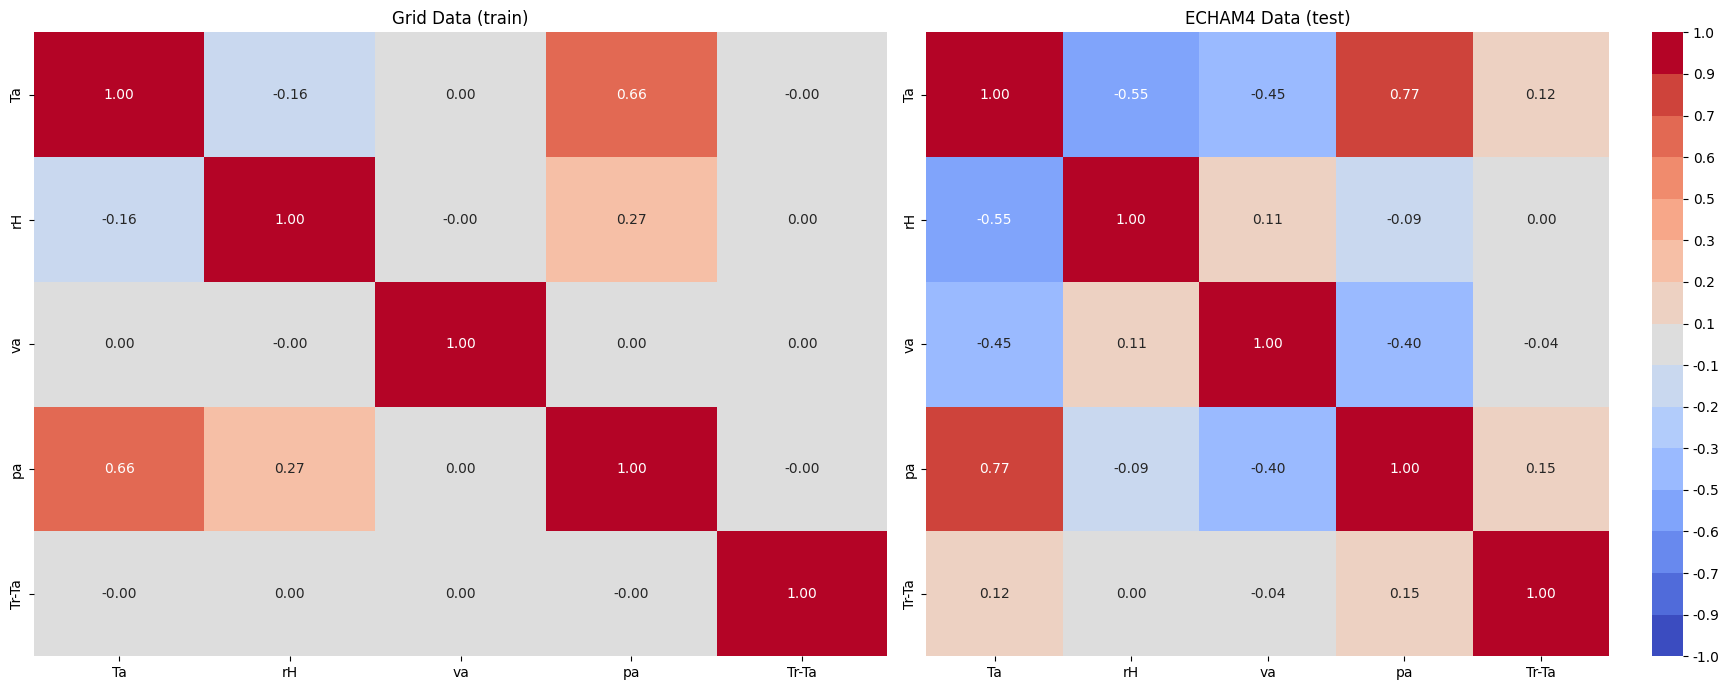

In [5]:

cols = ['Ta', 'rH', 'va', 'pa', 'Tr-Ta']

corr_esm4 = esm4[cols].corr(numeric_only=True)
corr_fiala = test_fiala[cols].corr(numeric_only=True)

# --- Create discrete color bins ---
bounds = np.linspace(-1, 1, 16)   # 8 discrete intervals
cmap = get_cmap("coolwarm", len(bounds) - 1)
norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Left: ESM4 ---
sns.heatmap(corr_esm4, annot=True, cmap=cmap, norm=norm,
            fmt=".2f", ax=axes[0], cbar=False)
axes[0].set_title("Grid Data (train)")

# --- Right: Fiala ---
heatmap = sns.heatmap(corr_fiala, annot=True, cmap=cmap, norm=norm,
                      fmt=".2f", ax=axes[1], cbar=True,
                      cbar_kws={"spacing": "proportional"})
axes[1].set_title("ECHAM4 Data (test)")

# Replace continuous colorbar with discrete ticks
colorbar = heatmap.collections[0].colorbar
colorbar.set_ticks(bounds)
colorbar.set_ticklabels([f"{b:.1f}" for b in bounds])

plt.tight_layout()
plt.show()



## Plot the data distributions

C:\Users\nerc-user\AppData\Local\Temp\ipykernel_30248\2294090061.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.98, 1.0])


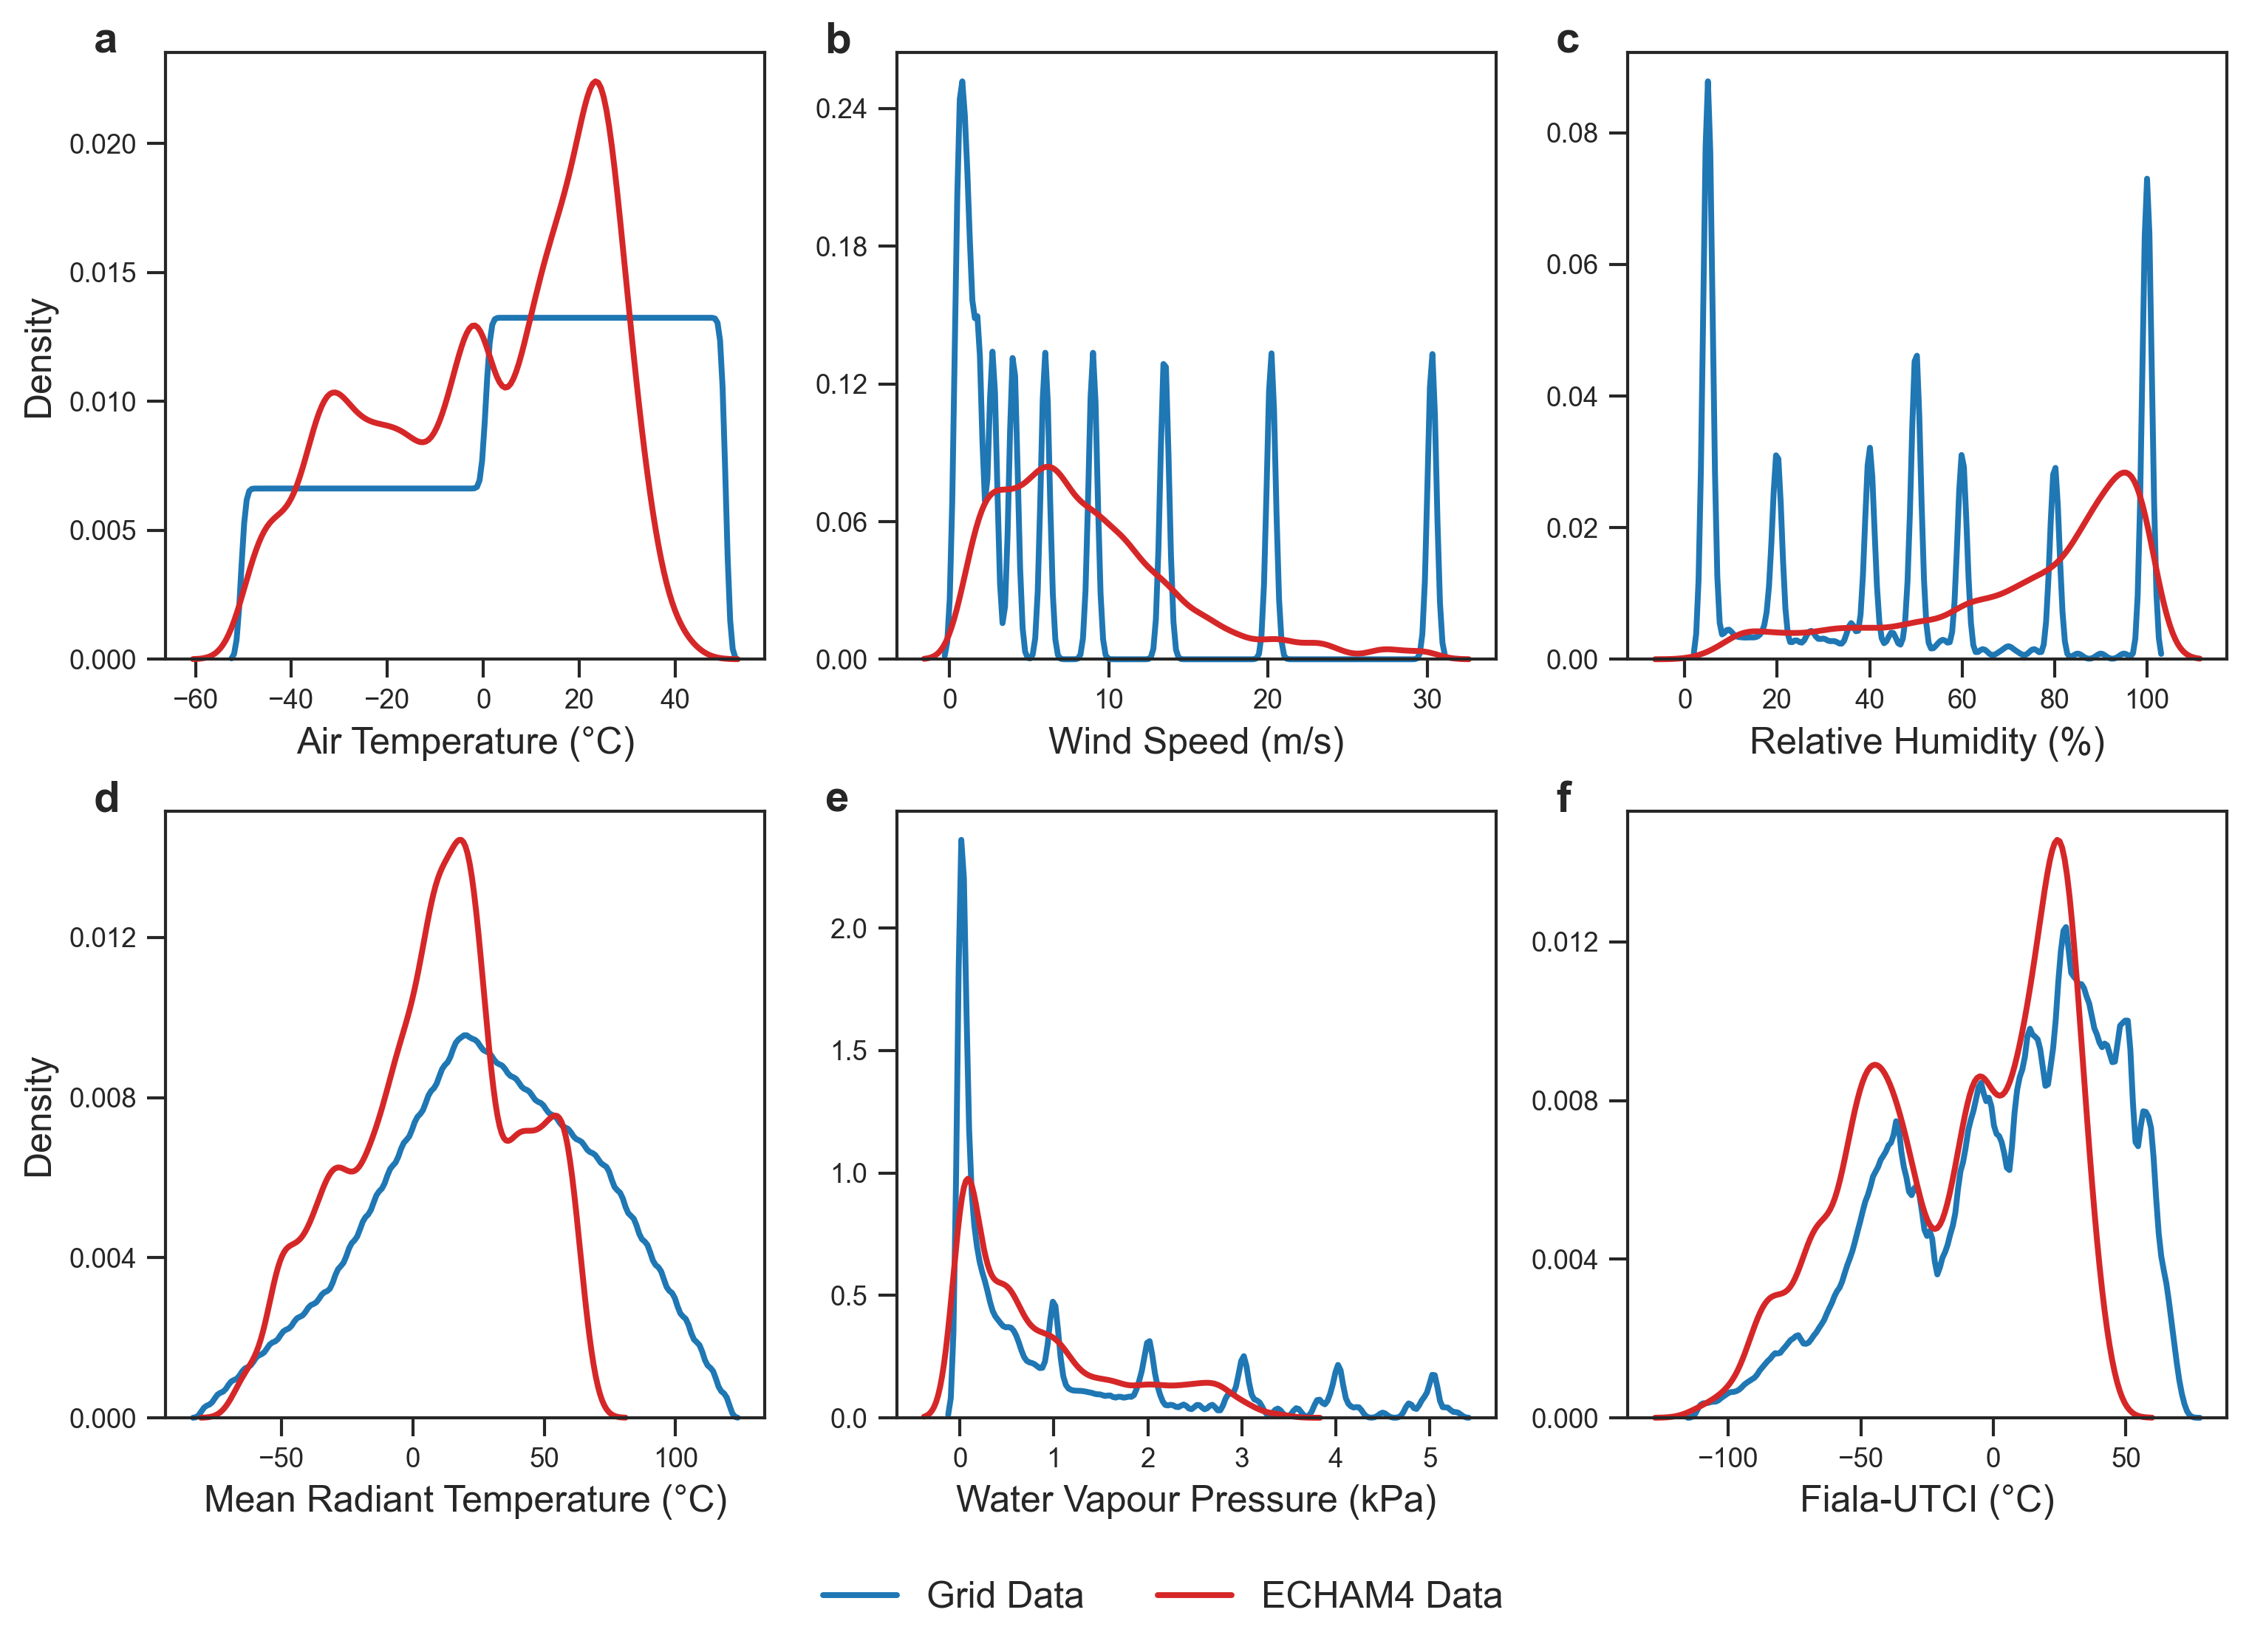

In [9]:


# ----------------- Publication-quality rc settings -----------------
mpl.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 600,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'axes.linewidth': 1.0,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'legend.frameon': False,
    'lines.linewidth': 1.5,
    'lines.markersize': 6,
    'axes.grid': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

sns.set_style("white")       # seaborn style - keep it clean
sns.set_context("paper")     # seaborn context


x_labels = {
    "Ta": "Air Temperature (°C)",
    "va": "Wind Speed (m/s)",
    "rH": "Relative Humidity (%)",
    "Tr": "Mean Radiant Temperature (°C)",
    "pa": "Water Vapour Pressure (kPa)",
    "UTCI": "Fiala-UTCI (°C)"
}

# ----------------- User parameters (tweak these) -----------------
vars_to_plot = ["Ta", "va", "rH", "Tr", "pa", "UTCI"]  # variables to plot
n_cols = 3
n_vars = len(vars_to_plot)
n_rows = math.ceil(n_vars / n_cols)
figsize = (12, 8)                       # figure size in inches
kde_bw_grid = {'Grid Data': 0.3, 'ECHAM4 Data': 0.6}  # bw_adjust for datasets
colors = {'Grid Data': '#1f77b4', 'ECHAM4 Data': '#d62728'}  # publication-friendly colors
line_styles = {'Grid Data': '-', 'ECHAM4 Data': '-'}
label_map = {'Grid Data': 'Grid Data', 'ECHAM4 Data': 'ECHAM4 Data'}

# ----------------- Create figure & axes (GridSpec ensures tight control) -----------------
fig = plt.figure(figsize=figsize)
gs = fig.add_gridspec(n_rows, n_cols, hspace=0.25, wspace=0.22)  # tweak spacing for publication
axes = []
for i in range(n_rows):
    for j in range(n_cols):
        ax = fig.add_subplot(gs[i, j])
        axes.append(ax)

# Flatten to have consistent indexing
axes = axes[:n_vars]  # in case there are extra subplots

# ----------------- Plot each KDE pair -----------------
for ax, var in zip(axes, vars_to_plot):
    # defensive: check if variable exists in dataframes
    if var not in df.columns and var not in test_fiala.columns:
        ax.text(0.5, 0.5, f"No column '{var}'", ha='center', va='center', fontsize=11, color='red')
        ax.set_title(var)
        ax.set_xlabel(var)
        ax.set_ylabel("Density")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        continue

    # Plot KDE: original dataset
    if var in esm4.columns:
        sns.kdeplot(
            data=esm4,
            x=var,
            ax=ax,
            fill=False,
            linewidth=1.9,
            label=label_map['Grid Data'],
            bw_adjust=kde_bw_grid['Grid Data'],
            clip_on=False,
            color=colors['Grid Data'],
            linestyle=line_styles['Grid Data']
        )

    # Plot KDE: test_fiala dataset
    if var in test_fiala.columns:
        sns.kdeplot(
            data=test_fiala,
            x=var,
            ax=ax,
            fill=False,
            linewidth=1.9,
            label=label_map['ECHAM4 Data'],
            bw_adjust=kde_bw_grid['ECHAM4 Data'],
            clip_on=False,
            color=colors['ECHAM4 Data'],
            linestyle=line_styles['ECHAM4 Data']
        )

    # Axis labels and title
    #ax.set_title(var, fontsize=13, pad=6)
    ax.set_ylabel("Density", fontsize=12)

    ax.set_xlabel(x_labels[var], fontsize=12) 

    # Tidy ticks and spines for publication look
    # ax.tick_params(axis='both', which='major', labelsize=11)
    # for spine in ['top', 'right']:
    #     ax.spines[spine].set_visible(False)

   

# ----------------- Add tick marks along x and y axes -----------------
for ax in axes:
    ax.tick_params(
        axis='both',
        which='major',
        length=6,         # tick length in points
        width=1.0,        # tick thickness
        direction='out',  # 'in', 'out', or 'inout'
        bottom=True, top=False,
        left=True, right=False,
    )

    ax.yaxis.set_major_locator(plt.MaxNLocator(5))



# ----------------- Only one y-axis label per row -----------------
for r in range(n_rows):
    # subplots belonging to this row
    row_axes = axes[r * n_cols : (r + 1) * n_cols]

    # keep y-label only on the first axis of each row
    for j, ax in enumerate(row_axes):
        if j == 0:
            continue  # keep y-label
        else:
            ax.set_ylabel("")        # remove label
            # Optional: hide tick labels for a cleaner look
            # ax.set_yticklabels([])


# ----------------- Create shared legend at bottom -----------------

# Collect handles/labels from the FIRST subplot (they are all the same)
handles, labels = axes[0].get_legend_handles_labels()


# Add a shared legend centered below all subplots
fig.legend(
    handles, labels,
    loc='lower center',
    ncol=2,                     # two entries: Grid Data + ECHAM4 Data
    bbox_to_anchor=(0.5, -0.02),  # adjust vertical spacing if needed
    frameon=False,
    fontsize=12
)

# ----------------- Panel labels (a, b, c, ...) -----------------
panel_labels = [chr(ord('a') + i) for i in range(n_vars)]
for idx, ax in enumerate(axes):
    ax.text(-0.12, 1.05, panel_labels[idx], transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left')

# ----------------- Final layout and saving -----------------
plt.tight_layout(rect=[0, 0, 0.98, 1.0])
# Save high-res outputs suitable for manuscripts
fig.savefig("../results/supplementary/data_distribution.png", dpi=600, bbox_inches="tight", pad_inches=0.01)
fig.savefig("../results/supplementary/data_distribution.pdf", dpi=600, bbox_inches="tight", pad_inches=0.01)

plt.show()
